# Import 


Library

In [6]:
import numpy as np            
import pandas as pd          
import matplotlib.pyplot as plt          
import seaborn as sns


CSV File

In [7]:

df = pd.read_csv("/Users/nick/python/fc_25/fc_25.csv",encoding = "utf-8-sig")

# Display 

In [8]:
# Allow output to display maximum number of columns
pd.set_option("display.max_columns", df.shape[1])  

In [9]:
# How data set looks like
df.loc[0:5]

,Name,Rating,Pace,Defense,Physical,Finishing,Vision,Control,Interception,Heading,Position,Foot,Height,Weight,Age,Country,League,Team
0,Kylian Mbappé,91,97,36,78,94,83,92,38,73,ST,Right,182,75,25,France,LALIGA EA SPORTS,Real Madrid
1,Rodri,91,66,87,85,74,84,90,84,81,CDM,Right,191,82,28,Spain,Premier League,Manchester City
2,Erling Haaland,91,88,45,88,96,74,83,43,83,ST,Left,195,94,24,Norway,Premier League,Manchester City
3,Jude Bellingham,90,80,78,83,90,90,89,82,75,CAM,Right,186,75,21,England,LALIGA EA SPORTS,Real Madrid
4,Vini Jr.,90,95,29,69,89,85,90,26,50,LW,Right,176,73,24,Brazil,LALIGA EA SPORTS,Real Madrid
5,Kevin De Bruyne,90,67,65,78,84,95,92,66,55,NaN,Right,181,75,33,Belgium,Premier League,Manchester City


In [10]:
# Infomation on each column
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16161 entries, 0 to 16160
Data columns (total 18 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Name          16161 non-null  object
 1   Rating        16161 non-null  int64 
 2   Pace          16161 non-null  int64 
 3   Defense       16161 non-null  int64 
 4   Physical      16161 non-null  int64 
 5   Finishing     16161 non-null  int64 
 6   Vision        16161 non-null  int64 
 7   Control       16161 non-null  int64 
 8   Interception  16161 non-null  int64 
 9   Heading       16161 non-null  int64 
 10  Position      13057 non-null  object
 11  Foot          16161 non-null  object
 12  Height        16161 non-null  int64 
 13  Weight        16161 non-null  int64 
 14  Age           16161 non-null  int64 
 15  Country       16161 non-null  object
 16  League        16161 non-null  object
 17  Team          16161 non-null  object
dtypes: int64(12), object(6)
memory usage: 2.2+ MB


# Modify Data Frame

In [11]:
# Check if there are duplicated rows
print("There are", df.duplicated().sum(), "duplicated rows")

There are 0 duplicated rows


In [12]:
# change all column to lower case 
df.columns  = df.columns.str.lower()

# sort column alphabetically
df = df[sorted(df)]

# lower case all values
df = df.apply(lambda value: value.str.lower() if (value.dtype == "object") else value)

# change all "gk" in position column to null & drop affected rows 
df[["position"]]= df[["position"]].replace(["gk"],np.nan)
df = df.dropna(axis="index",how="all",subset=["position"])

# Exploratory Analysis

Which country produce better (above average) players?

/var/folders/zx/hp3k08xs3sgg687y9sqn3bcc0000gn/T/ipykernel_57810/4088037015.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=player_country_count.index, y=player_country_count.values, palette='coolwarm')


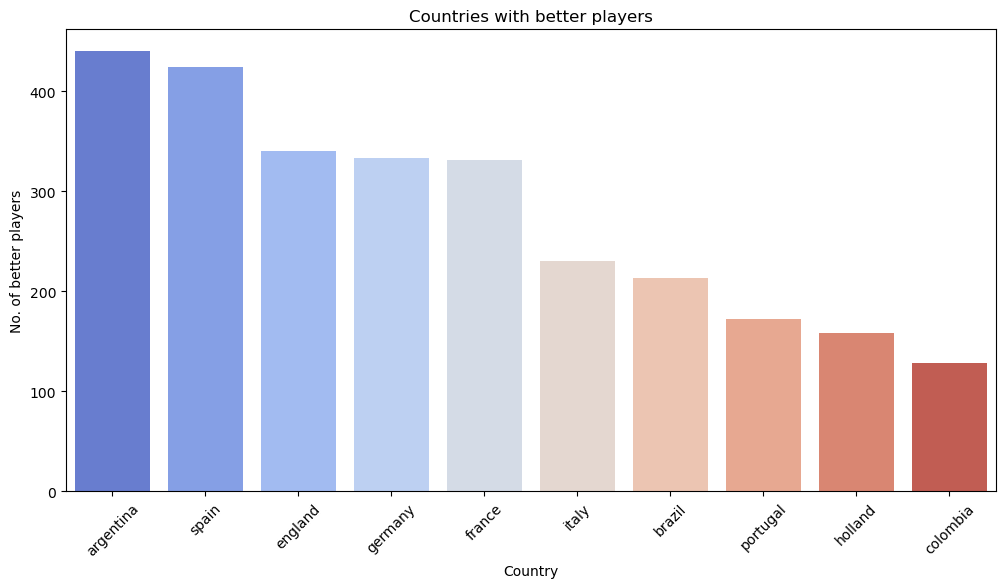

In [13]:
# Filter better players (Those with rating that exceed average)
better_players = df[df['rating'] > df['rating'].mean()]

# Top 10 country based on player count
player_country_count = better_players['country'].value_counts().nlargest(10)

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(x=player_country_count.index, y=player_country_count.values, palette='coolwarm')
plt.title("Countries with better players")
plt.xlabel('Country')
plt.ylabel('No. of better players')
plt.xticks(rotation=45)
plt.show()

Which league is the most competitive?

/var/folders/zx/hp3k08xs3sgg687y9sqn3bcc0000gn/T/ipykernel_57810/2612244995.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_league.index, y=top_league.values, palette='magma')


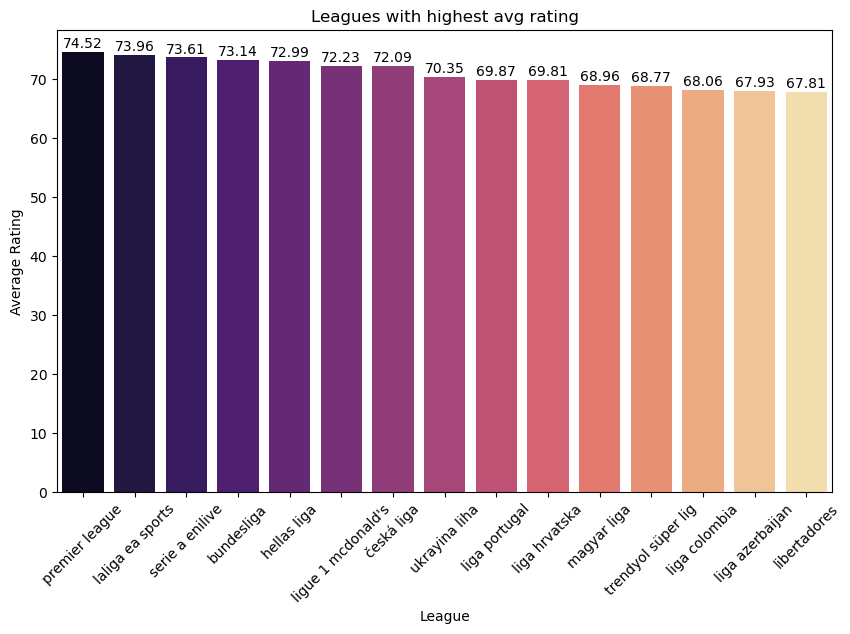

In [14]:
# Group by league then calculate average rating within each league
top_league = df.groupby("league")["rating"].mean().nlargest(15)
# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x=top_league.index, y=top_league.values, palette='magma')
plt.title('Leagues with highest avg rating')
plt.xlabel('League')
plt.ylabel('Average Rating')
plt.xticks(rotation=45)

# Annotate average rating on bars
for i, avg_rating in enumerate(top_league.values):
    plt.text(i, avg_rating + 0.2, f"{avg_rating:.2f}", ha='center', va='bottom')

plt.show()

Which team is the strongest  in the Premier League (PL)?

In [28]:
# Filter premier league teams
premier_league = df[df["league"]=="premier league"]

# Group by team then sort top 5 based on average rating
print("The strongest teams are:\n" , round(premier_league.groupby("team")["rating"].mean().nlargest(5),2))

The strongest teams are:
 team
liverpool          79.33
manchester city    78.61
arsenal            78.37
newcastle utd      76.24
spurs              76.19
Name: rating, dtype: float64


Which position has older players?


/var/folders/zx/hp3k08xs3sgg687y9sqn3bcc0000gn/T/ipykernel_57810/3479376117.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='position', y='age', data=df, order=avg_age_position.index, palette='viridis')


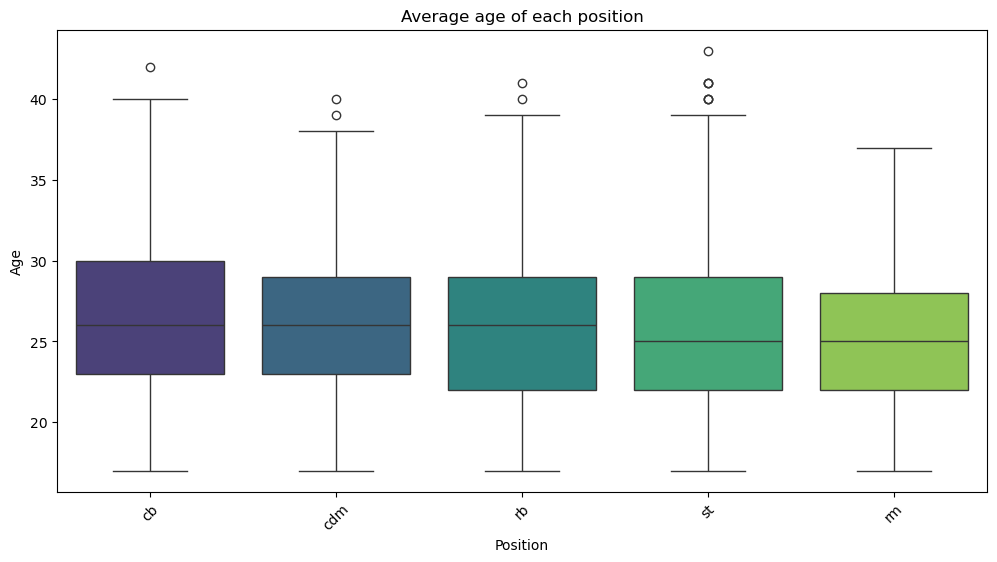

In [16]:
# Group by position then sort by average age
avg_age_position = df.groupby('position')['age'].mean().sort_values(ascending=False).nlargest(5)

# Plot to visualize
plt.figure(figsize=(12, 6))
sns.boxplot(x='position', y='age', data=df, order=avg_age_position.index, palette='viridis')
plt.title("Average age of each position")
plt.xlabel('Position')
plt.ylabel('Age')
plt.xticks(rotation=45)
plt.show()

Are there many elite players? 

3.0 % of players are elite


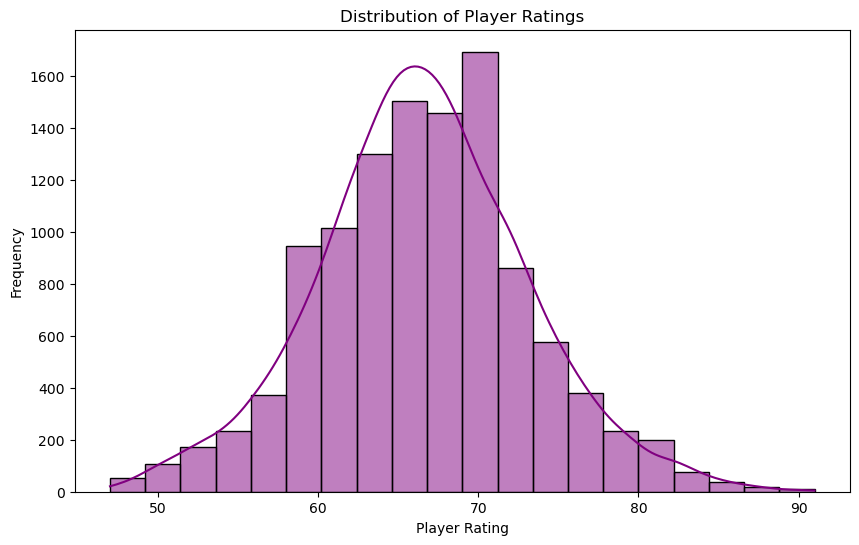

In [18]:
# Filter elite players (rating >= 80)
elite = df[df["rating"] >= 80]
print(round((elite.shape[0]/df.shape[0])*100,2), "% of players are elite")

# Plot 
plt.figure(figsize=(10, 6))
sns.histplot(df['rating'], bins=20, kde=True, color='purple')
plt.title('Distribution of Player Ratings')
plt.xlabel('Player Rating')
plt.ylabel('Frequency')
plt.show()

What is the best attribute among elite players? 


In [19]:
# Filter elite players
elite_players = df[df['rating'] >=  80]

# Add attributess
attributes = elite_players[["pace","defense","physical","finishing","vision","control"]]

# Print best attribute based on average scores
print("Attribute:\n",(round(attributes.agg("mean"),2).sort_values(ascending=False)))


Attribute:
 control      80.70
physical     75.10
pace         74.64
vision       74.64
finishing    67.88
defense      62.70
dtype: float64


Which position requires better vision ?

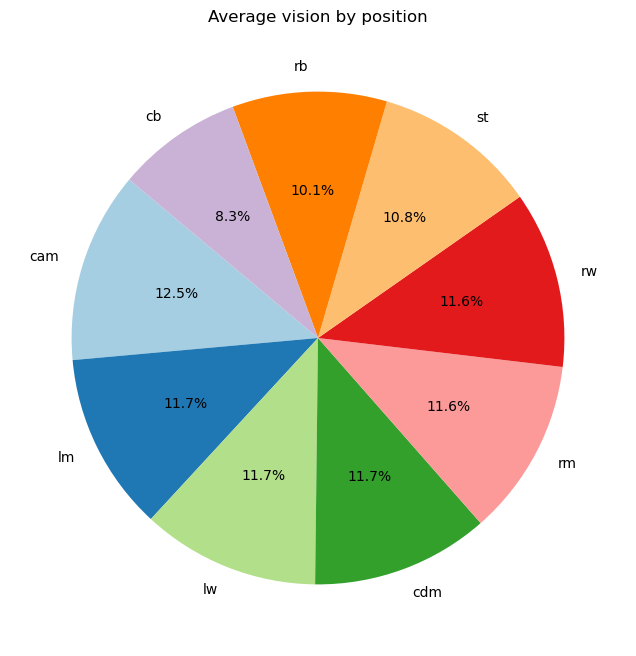

In [21]:
# Group by position then calculate average vision score
avg_vision_position = df.groupby("position")["vision"].mean().sort_values(ascending=False)


# Plotting the pie chart
plt.figure(figsize=(8, 8))
plt.pie(avg_vision_position, labels=avg_vision_position.index, autopct='%1.1f%%', startangle=140, colors=plt.cm.Paired.colors)
plt.title('Average vision by position')
plt.show()

Is there a preferred foot in each position?

<Figure size 1000x600 with 0 Axes>

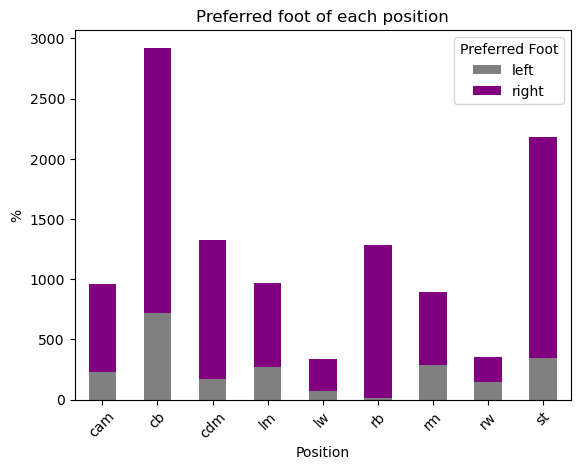

In [22]:
# Group by position and foot
foot_position = df.groupby(['position', 'foot']).size().unstack()

# Calculate the percentage of preferred foot within each position
foot_position_pct = foot_position.div(foot_position.sum(axis=1), axis=0) * 100

# Plotting the results
plt.figure(figsize=(10, 6))
foot_position.plot(kind='bar', stacked=True,color=['#808080', '#800080'])
plt.title('Preferred foot of each position')
plt.xlabel('Position')
plt.ylabel('%')
plt.legend(title='Preferred Foot', loc='upper right')
plt.xticks(rotation=45)
plt.show()